
## Data

Monthly with and without dividend returns of the value weighted portfolio of all NYSE, Amex, and NASDAQ stocks from 1944 to 2007 and 2024.

30-day T-bill rate from 1944 to 2007 and 2024.

The reason for needing the data from 1944 instead of 1946 was due to the construction of certain parameters requiring data from previous years. 

We have return data to 2026 but we stop at 2024 because the lastest t-bill rate data is till 2024.  

We show case data from 1944 to 2024 here.

In [8]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tbill_df_latest = pd.read_parquet("../_data/CRSP_30_day_T_bill_44_to_latest.parquet")
ret_df_latest = pd.read_parquet("../_data/CRSP_monthly_stock_44_to_latest.parquet")

Below is 30-day T-bill rate from 1944 to 2024.

In [9]:
tbill_df_latest.head()

,date,t30ret
0,1944-01-31,0.000293
1,1944-02-29,0.000289
2,1944-03-31,0.000238
3,1944-04-29,0.000277
4,1944-05-31,0.000261


Sanity check: T-bill rate should usually be above 0.

In [10]:
condition = tbill_df_latest['t30ret'] <= 0
count_true = condition.sum()
print(f"Number of months where T-bill Rate <= 0: {count_true}")

condition_true_rows = tbill_df_latest[condition]
print(condition_true_rows)

Number of months where T-bill Rate <= 0: 11
          date    t30ret
810 2011-07-29 -0.000028
812 2011-09-30 -0.000001
815 2011-12-30  0.000000
816 2012-01-31 -0.000002
850 2014-11-28 -0.000001
853 2015-02-27 -0.000021
854 2015-03-31 -0.000008
856 2015-05-29 -0.000005
858 2015-07-31 -0.000037
860 2015-09-30 -0.000006
861 2015-10-30 -0.000027


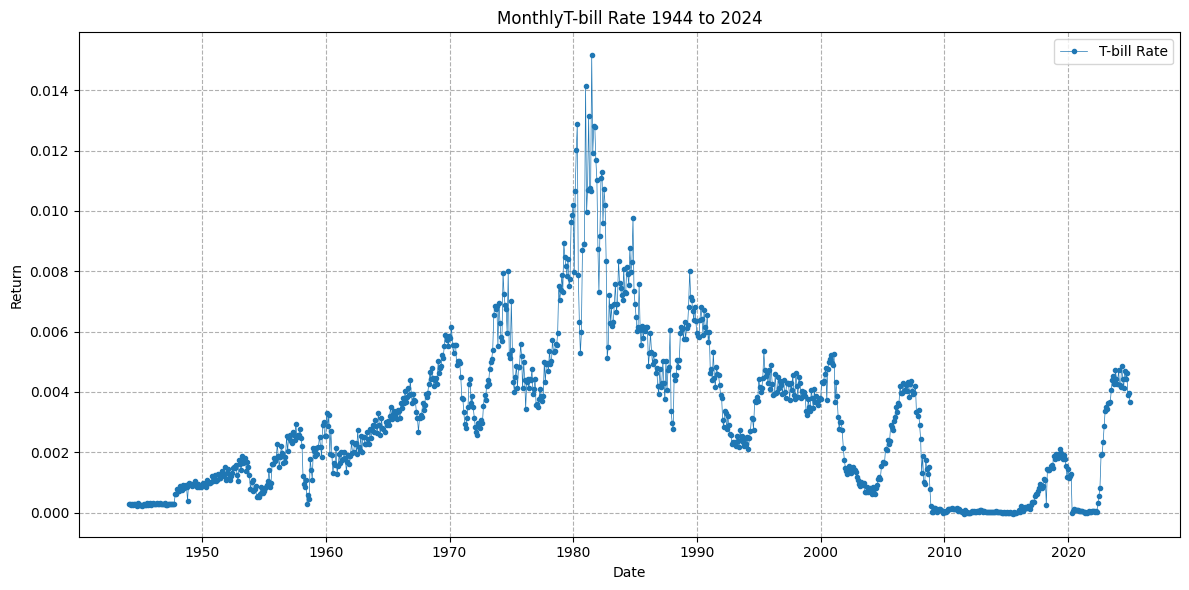

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(tbill_df_latest['date'], tbill_df_latest['t30ret'], label='T-bill Rate', marker='.', linestyle='-', linewidth=0.5)

years = range(1950, 2021, 10)
ax.set_xticks([pd.Timestamp(year=year, month=1, day=1) for year in years])
ax.set_xticklabels([str(year) for year in years])

ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.set_title('MonthlyT-bill Rate 1944 to 2024')
ax.legend()
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Below is monthly with (vwretd) and without (vwretx) dividend returns of the value weighted portfolio of all NYSE, Amex, and NASDAQ stocks from 1944 to 2024.

In [13]:
ret_df_latest.tail()

,date,vwretd,vwretx
980,2025-09-30,0.035627,0.034163
981,2025-10-31,0.019285,0.018508
982,2025-11-28,0.001994,0.000849
983,2025-12-31,0.001296,-0.000601
984,2026-01-30,0.018201,0.017427


Sanity check: return with dividend should always be bigger than without.

In [6]:
condition = ret_df_latest['vwretd'] <= ret_df_latest['vwretx']

count_true = condition.sum()
print(f"Number of rows with vwretd <= vwretx: {count_true}")

Number of rows with vwretd <= vwretx: 0


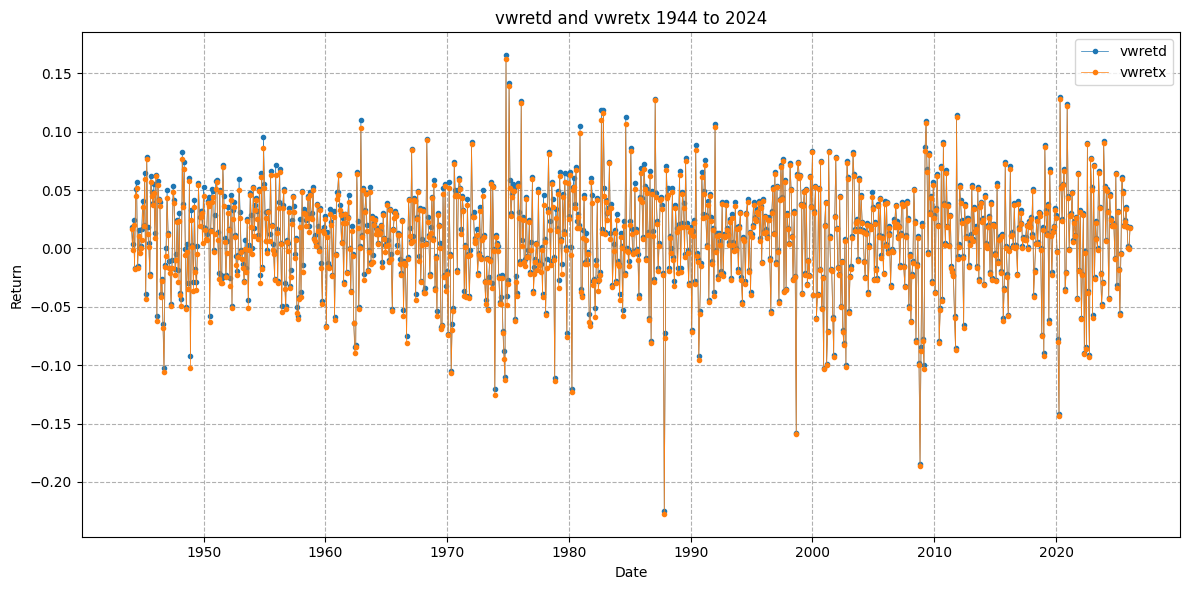

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ret_df_latest['date'], ret_df_latest['vwretd'], label='vwretd', marker='.', linestyle='-', linewidth=0.5)
ax.plot(ret_df_latest['date'], ret_df_latest['vwretx'], label='vwretx', marker='.', linestyle='-', linewidth=0.5)

years = range(1950, 2021, 10)
ax.set_xticks([pd.Timestamp(year=year, month=1, day=1) for year in years])
ax.set_xticklabels([str(year) for year in years])

ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.set_title('vwretd and vwretx 1944 to 2024')
ax.legend()
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()